# Federated vs Centralized Training Comparison

This notebook demonstrates a comparison between **Federated Learning (FL)** and **Centralized Training** for a binary classification task using PyTorch.

The routines here are condensed for clarity but preserve full functionality:
- **Federated Training**: Clients train locally and share model weights for aggregation via `FedAvg`.
- **Centralized Training**: A single model is trained on all combined data as a baseline.
- **Evaluation Metrics**: F1-score, precision, recall, and loss are logged and visualized.

---


## Imports

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy
import csv

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
OUTPUT_DIR = os.path.join("..", "History", "original_comparison")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Saving section CSVs to: {OUTPUT_DIR}")

Saving section CSVs to: ..\History\original_comparison


## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [3]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [4]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

In [5]:
def save_dict_rows_to_csv(rows: list[dict], filepath: str) -> None:
    """
    Save a list of dictionaries to a CSV file.
    """
    if not rows:
        print(f"[save_dict_rows_to_csv] No rows to save for {filepath}")
        return

    fieldnames = []
    seen = set()
    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with open(filepath, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved CSV: {filepath}")

def to_serializable_row(row: dict) -> dict:
    """
    Convert metric values to plain Python scalars when possible.
    """
    cleaned = {}
    for k, v in row.items():
        if isinstance(v, (np.floating, np.integer)):
            cleaned[k] = v.item()
        elif isinstance(v, torch.Tensor):
            cleaned[k] = v.item() if v.numel() == 1 else v.detach().cpu().tolist()
        else:
            cleaned[k] = v
    return cleaned

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [6]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [7]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


# Example: Instantiate the model
model = GenerateModel(table_path=os.path.join("..", "Model", "processed_full.w2v")).to(device)
model

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (embed_drop): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
)

## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [8]:
# FedAvg - working with parameter dictionary rather than deepcopy

def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.

    Args:
        global_model (dict): Global model parameter dictionary (in-place update).
        client_state_dicts (list[dict]): List of parameter dictionaries from clients.

    Returns:
        dict: Updated global parameter dictionary (averaged across clients).
    """
    for key in global_model.keys():
        # Stack corresponding parameters from all clients and take mean
        stacked = torch.stack(
            [client_dict[key].float() for client_dict in client_state_dicts],
            dim=0
        )
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [9]:
# Example of Fed Averaging

g_param = {
    "layer1": torch.zeros(size=(4, 4))
}

# Simulate 3 clients with random local parameters
c_param = [
    {"layer1": torch.randint(low=0, high=10, size=(4, 4))}
    for _ in range(3)
]

print("🧱 Global Model (Before Aggregation):\n", g_param["layer1"])
print("\nClient Models:")
for i, client in enumerate(c_param, start=1):
    print(f"Client {i}:\n", client["layer1"])

# Perform federated averaging
g_param = FedAvg(global_model=g_param, client_state_dicts=c_param)

print("\n🌐 Global Model (After FedAvg):\n", g_param["layer1"])


🧱 Global Model (Before Aggregation):
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Client Models:
Client 1:
 tensor([[6, 2, 9, 9],
        [2, 5, 2, 6],
        [6, 3, 0, 3],
        [0, 7, 1, 2]])
Client 2:
 tensor([[9, 6, 8, 8],
        [0, 4, 7, 8],
        [7, 9, 0, 5],
        [0, 1, 7, 9]])
Client 3:
 tensor([[8, 3, 4, 3],
        [5, 1, 7, 6],
        [4, 9, 3, 8],
        [0, 4, 6, 9]])

🌐 Global Model (After FedAvg):
 tensor([[7.6667, 3.6667, 7.0000, 6.6667],
        [2.3333, 3.3333, 5.3333, 6.6667],
        [5.6667, 7.0000, 1.0000, 5.3333],
        [0.0000, 4.0000, 4.6667, 6.6667]])


### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [10]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [11]:
# Create focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_term = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


In [12]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5
) -> tuple[float, dict]:
    """
    Perform local training for a single client using weighted BCE loss.

    Args:
        model (nn.Module): Model to train.
        train_loader (DataLoader): Client's local dataset.
        epochs (int): Number of local training epochs (default: 1).
        lr (float): Learning rate for Adam optimizer (default: 0.1).
        device (str): Computation device ('cpu' or 'cuda').

    Returns:
        tuple:
            - float: Final loss value from the last batch.
            - dict: Trained model's state_dict after local updates.
    """
    model.to(device)
    model.train()

    # ---- Compute pos_weight (to handle imbalance) ----
    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    # ---- Optimizer and Loss ----
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
    # ---- Choose between BCE and Focal ----
    if use_focal:
         # Smooth alpha to prevent extreme imbalance
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # ---- Local Training ----
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return loss.item(), {k: v.detach().clone() for k, v in model.state_dict().items()}


In [13]:
# Example of local client update

train_loader = load_data(split="train")

local_loss, local_params = client_update(
    model=model,
    train_loader=train_loader,
    epochs=1,
    device="cpu"
)

print(f"📉 Local Training Loss: {local_loss:.4f}")
print("🔧 Example Parameter (embed.weight):\n", local_params["embed.weight"])


📉 Local Training Loss: 0.8488
🔧 Example Parameter (embed.weight):
 tensor([[ 1.3710e+00, -1.1058e+00,  2.0421e+00,  ..., -2.6081e+00,
          9.1003e-01,  8.2254e-01],
        [ 1.5817e+00, -4.5227e-01,  4.5332e-01,  ...,  1.7618e-01,
          7.6717e-01,  1.1082e+00],
        [ 6.9607e-01,  6.6233e-01, -8.9618e-01,  ..., -4.3699e-01,
          7.8535e-01,  1.9697e+00],
        ...,
        [ 7.2904e-03, -9.4383e-04, -2.5926e-02,  ...,  1.3076e-02,
         -2.7830e-02,  1.5075e-02],
        [ 5.7946e-03,  3.3857e-03,  2.6939e-02,  ..., -1.9374e-02,
          2.0232e-02,  1.2402e-02],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])


## Federated Training — Full Experiment Pipeline

This section coordinates the **federated learning process**:
1. Initializes global and client models.
2. Splits the dataset into client partitions.
3. Iteratively performs:
   - Local training (`client_update`)
   - Model aggregation (`FedAvg`)
   - Periodic evaluation and checkpointing

Metrics are saved incrementally to `../History/logs/metric_history.json`, and the best models (by AUC and F1) are checkpointed.


### Set up

In [14]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,            #how many times clint will go through its own local dataset each round
    "rounds": 100,           #for centralized, this is the epochs
    "use_focal" : False,
    "gamma" : 2.5
}

model_param_path = os.path.join("..", "Model", "processed_full.w2v")

Global train size: torch.Size([6453, 50])
Client 1 size: torch.Size([2130, 50])
Client 2 size: torch.Size([2129, 50])
Client 3 size: torch.Size([2194, 50])


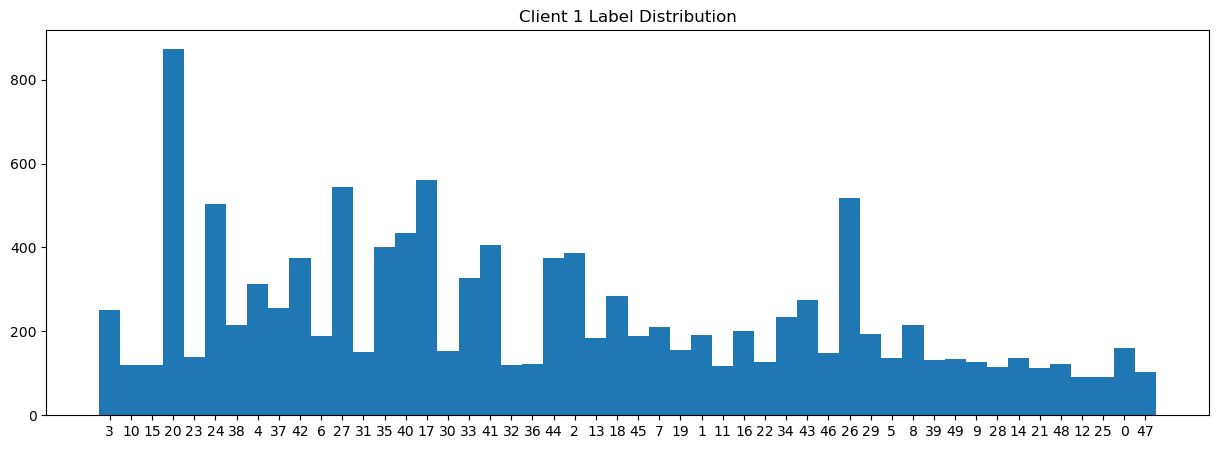

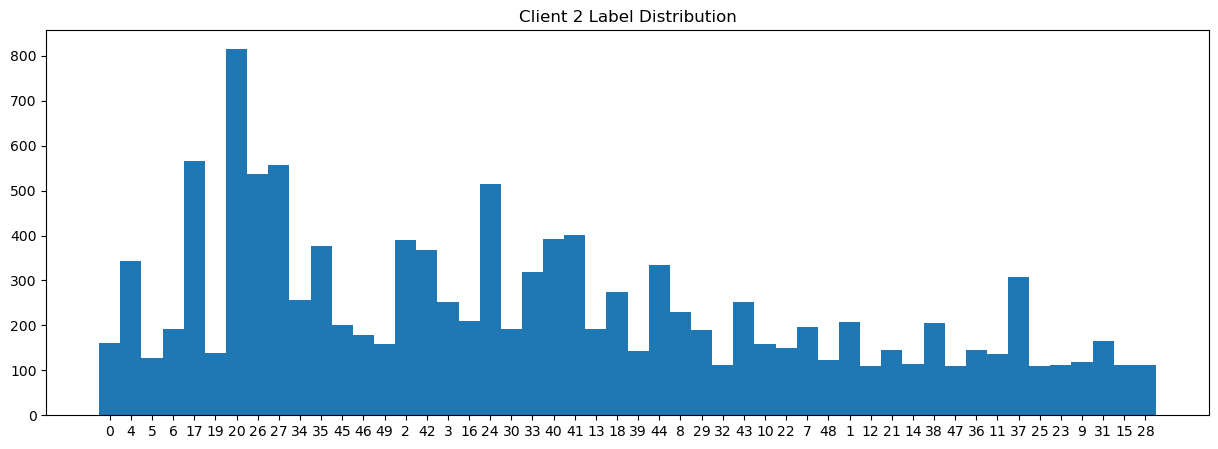

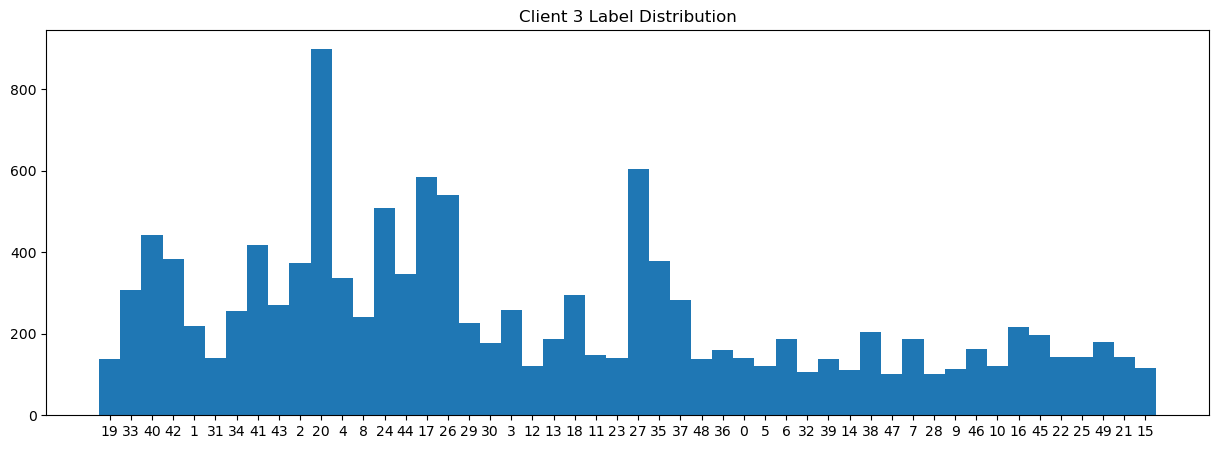

In [15]:
# Client data partitioning

# Load full training data
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

# Split dataset into three clients
c1, c2, c3 = random_split(train_dataset, lengths=[0.33, 0.33, 0.34])
c_loaders = [
    DataLoader(c, batch_size=config["batch_size"], shuffle=True)
    for c in [c1, c2, c3]
]

# Display data distribution
print(f"Global train size: {train_dataset.tensors[1].shape}")
for i, c in enumerate([c1, c2, c3], start=1):
    print(f"Client {i} size: {Y_train[c.indices].shape}")

# Plot label distributions for each client
for idx, c in enumerate([c1, c2, c3]):
    all_codes = [code for instance in Y_train[c.indices]
                 for code in torch.where(instance > 0)[0].tolist()]
    counts = Counter(all_codes)
    labels, values = zip(*counts.items())

    plt.figure(figsize=(15, 5))
    plt.title(f"Client {idx + 1} Label Distribution")
    plt.bar(range(len(labels)), values, 1)
    plt.xticks(range(len(labels)), labels)
    plt.show()

In [16]:
# Model intialization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Global_Model = GenerateModel(
    table_path=model_param_path,
    num_of_filters=config["n_filters"],
    kernel_size=config["window_size"]
).to(device)

client = GenerateModel(
    table_path=model_param_path,
    num_of_filters=config["n_filters"],
    kernel_size=config["window_size"]
).to(device)

val_loader = load_data(split="val")

# ---- Optional but recommended: bias init for fairness ----
n_labels = val_loader.dataset[0][1].shape[0]
pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

with torch.no_grad():
    p = pos_weight / (pos_weight + 1.0)
    prior_logit = torch.log(p / (1 - p))
    Global_Model.final.bias.copy_(prior_logit.clamp(-10, 10))
    client.final.bias.copy_(prior_logit.clamp(-10, 10))  # for symmetry

Using device: cuda


### Eval stuff

In [18]:
# Auto tuning to find best global threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one 
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [19]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [20]:
@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold=False,
    fixed_thr=0.3,
    sigmoid=False,
    per_label_thr=None,  # <-- new argument
    use_focal=False,
    alpha=None,
    gamma=2.5
):
    """
    Evaluate model performance on a given dataset using BCEWithLogitsLoss.
    Supports:
        - Fixed threshold (fixed_thr)
        - Tuned global threshold (tune_threshold)
        - Per-label thresholds (per_label_thr)
    """
    model.eval()
    model.to(device)

    if use_focal:
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    # ---- Forward pass ----
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()

        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    # ---- Diagnostics: logit + sigmoid range ----
    logit_min, logit_max = all_pred_raw.min().item(), all_pred_raw.max().item()
    sigmoid_vals = torch.sigmoid(all_pred_raw)
    print(f"[Eval Debug] Logit range: {logit_min:.2f} to {logit_max:.2f} | "
          f"Sigmoid mean={sigmoid_vals.mean():.3f}, std={sigmoid_vals.std():.3f}")

    # Optional visualization (uncomment if needed)
    if sigmoid:
        plt.hist(sigmoid_vals.cpu().numpy().flatten(), bins=50)
        plt.title("Sigmoid Output Distribution")
        plt.xlabel("Predicted Probability")
        plt.ylabel("Count")
        plt.show()

    # ---- Apply thresholds ----
    if per_label_thr is not None:
        # Use per-label thresholds vector
        pred_labels = (sigmoid_vals >= per_label_thr.to(device)).long()
        used_thr = "per-label"
        best_f1, best_thr = None, "per-label"
    else:
        # Use fixed or tuned global threshold
        pred_labels = (sigmoid_vals >= fixed_thr).long()
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

        best_f1, best_thr = metrics["f1_micro"], fixed_thr
        if tune_threshold:
            best_f1, best_thr = find_best_threshold(model, data_loader, device)

    # ---- Compute metrics (recomputed if per_label_thr used) ----
    if per_label_thr is not None:
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

    # ---- Avg predicted labels per sample ----
    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    # ---- Print evaluation summary ----
    print(f"[Eval] Avg loss={avg_loss:.4f} | F1_micro={metrics['f1_micro']:.4f} | "
          f"Best_F1={best_f1 if best_f1 else metrics['f1_micro']:.4f} @ thr={best_thr} | "
          f"Avg labels/sample={avg_pred_labels:.2f}")

    # ---- Store for history ----
    metrics["best_f1_micro"] = best_f1 if best_f1 else metrics["f1_micro"]
    metrics["best_thr"] = best_thr

    return avg_loss, metrics


### Gamma tuning Experiment

In [21]:
# --- Quick gamma tuning experiment ---
gamma_values = [1.0, 1.5, 2.0, 2.5, 3.0]
results = {}
gamma_rows = []

for gamma in gamma_values:
    print(f"\n===== Testing gamma={gamma} =====")
    config["gamma"] = gamma

    # Reinitialize model fresh each run
    model = GenerateModel(
        table_path=model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], betas=(0.9, 0.99))

    alpha = (pos_weight / pos_weight.max()).to(device)
    loss_fn = FocalLoss(alpha=alpha, gamma=gamma)

    # --- Short training run ---
    for epoch in range(5):  # small number for speed
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/5 | Train Loss: {avg_train_loss:.4f}")

    # --- Evaluate F1 on validation set ---
    macro_f1_thr, per_label_thr = find_best_thresholds_per_label(model, val_loader, device)
    val_loss, metrics = eval_model(model, device, val_loader, per_label_thr=per_label_thr)
    results[gamma] = metrics["f1_micro"]

    gamma_rows.append({
        "gamma": float(gamma),
        "train_loss_last_epoch": float(avg_train_loss),
        "val_loss": float(val_loss),
        "f1_micro": float(metrics["f1_micro"]),
        "f1_macro": float(metrics["f1_macro"]),
        "auc_micro": float(metrics["auc_micro"]),
        "auc_macro": float(metrics["auc_macro"]),
        "per_label_macro_f1": float(macro_f1_thr)
    })

print("\nGamma tuning results:")
for g, f1 in results.items():
    print(f"γ={g}: F1_micro={f1:.4f}")

best_gamma = max(results, key=results.get)
print(f"\nBest gamma: {best_gamma} (F1_micro={results[best_gamma]:.4f})")
config["gamma"] = best_gamma

save_dict_rows_to_csv(
    gamma_rows,
    os.path.join(OUTPUT_DIR, "gamma_tuning_results.csv")
)


===== Testing gamma=1.0 =====
Epoch 1/5 | Train Loss: 0.0778
Epoch 2/5 | Train Loss: 0.0637
Epoch 3/5 | Train Loss: 0.0595
Epoch 4/5 | Train Loss: 0.0565
Epoch 5/5 | Train Loss: 0.0535
[Per-Label Thresholds] Macro F1=0.4345
[Eval Debug] Logit range: -5.33 to 5.93 | Sigmoid mean=0.240, std=0.190
[Eval] Avg loss=0.4475 | F1_micro=0.4236 | Best_F1=0.4236 @ thr=per-label | Avg labels/sample=12.23

===== Testing gamma=1.5 =====
Epoch 1/5 | Train Loss: 0.0544
Epoch 2/5 | Train Loss: 0.0449
Epoch 3/5 | Train Loss: 0.0420
Epoch 4/5 | Train Loss: 0.0397
Epoch 5/5 | Train Loss: 0.0380
[Per-Label Thresholds] Macro F1=0.4352
[Eval Debug] Logit range: -4.97 to 5.59 | Sigmoid mean=0.273, std=0.178
[Eval] Avg loss=0.4596 | F1_micro=0.4225 | Best_F1=0.4225 @ thr=per-label | Avg labels/sample=12.42

===== Testing gamma=2.0 =====
Epoch 1/5 | Train Loss: 0.0394
Epoch 2/5 | Train Loss: 0.0317
Epoch 3/5 | Train Loss: 0.0294
Epoch 4/5 | Train Loss: 0.0278
Epoch 5/5 | Train Loss: 0.0266
[Per-Label Threshold

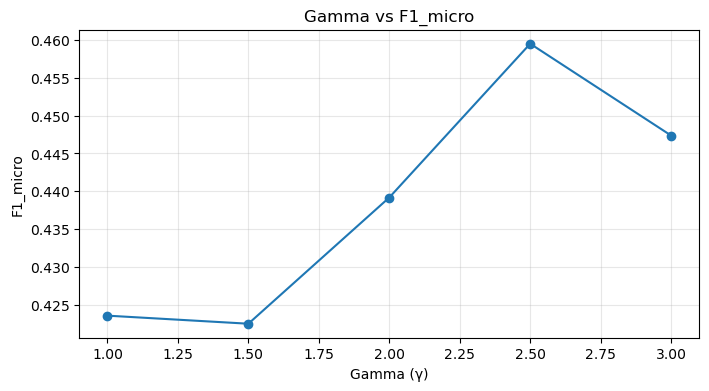

In [22]:
# Gamma plot

plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Gamma vs F1_micro")
plt.xlabel("Gamma (γ)")
plt.ylabel("F1_micro")
plt.grid(alpha=0.3)
plt.show()

### Main training loop

In [23]:
# Federated history setup

history = {
    "local_loss": {0: [], 1: [], 2: []},
    "global_loss": [],
    "global_metrics": []
}

max_auc_macro = 0.0
max_f1_micro = 0.0

FED_LOCAL_CSV = os.path.join(OUTPUT_DIR, "federated_local_losses.csv")
FED_EVAL_CSV = os.path.join(OUTPUT_DIR, "federated_eval_history.csv")
FED_PROGRESS_JSON = os.path.join(OUTPUT_DIR, "federated_progress.json")
FED_HISTORY_JSON = "../History/logs/metric_history.json"
FED_LATEST_MODEL = "../History/logs/latest_model.pt"
FED_MAX_AUC_MODEL = "../History/logs/max_auc.pt"
FED_MAX_F1_MODEL = "../History/logs/max_f1_micro.pt"

In [24]:
# Federated training loop 

fed_local_loss_rows = []
fed_eval_rows = []

resume_fed = False
start_round = 0

if (
    resume_fed
    and os.path.exists(FED_LATEST_MODEL)
    and os.path.exists(FED_HISTORY_JSON)
    and os.path.exists(FED_PROGRESS_JSON)
):
    print("Found federated checkpoint. Resuming run...")

    Global_Model.load_state_dict(torch.load(FED_LATEST_MODEL, map_location=device))
    history = load_json(FED_HISTORY_JSON)
    progress = load_json(FED_PROGRESS_JSON)

    start_round = progress["last_completed_round"]

    if os.path.exists(FED_LOCAL_CSV):
        import pandas as pd
        fed_local_loss_rows = pd.read_csv(FED_LOCAL_CSV).to_dict(orient="records")

    if os.path.exists(FED_EVAL_CSV):
        import pandas as pd
        fed_eval_rows = pd.read_csv(FED_EVAL_CSV).to_dict(orient="records")

    if len(history["global_metrics"]) > 0:
        max_auc_macro = max(m["auc_macro"] for m in history["global_metrics"])
        max_f1_micro = max(m["f1_micro"] for m in history["global_metrics"])

    print(f"Restarting at round {start_round + 1}")
else:
    print("No federated checkpoint found. Starting fresh.")

config["rounds"] = 100  # important for testing time
target_evals = 100
eval_interval = max(1, round(config["rounds"] / target_evals))

for rnd in tqdm(range(start_round, config["rounds"]), colour="blue"):
    client_params = []
    total_local_loss = 0.0  # for averaging client losses

    # ---- Local training on each client ----
    for c_idx, loader in enumerate(c_loaders):
        client.load_state_dict(Global_Model.state_dict())

        local_loss, c_param = client_update(
            model=client,
            train_loader=loader,
            epochs=config["epochs"],
            lr=config["lr"],
            device=device,
            use_focal=config["use_focal"],
            gamma=config["gamma"]
        )

        client_params.append(c_param)
        history["local_loss"][c_idx].append(local_loss)
        total_local_loss += local_loss

        # for saving
        fed_local_loss_rows.append({
            "round": rnd + 1,
            "client": c_idx,
            "local_loss": float(local_loss)
        })

    avg_local_loss = total_local_loss / len(c_loaders)

    # ---- Aggregation step ----
    new_param = FedAvg(Global_Model.state_dict(), client_params)
    Global_Model.load_state_dict(new_param)

    # ---- Evaluation phase (same as centralized) ----
    if (rnd + 1) % eval_interval == 0 or rnd == config["rounds"] - 1:
        # Compute per-label thresholds dynamically for this checkpoint
        _, per_label_thr = find_best_thresholds_per_label(Global_Model, val_loader, device)
        g_loss, metrics = eval_model(
            Global_Model, device, val_loader,
            per_label_thr=per_label_thr,
            use_focal=config["use_focal"],
            alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device), 
            gamma=config["gamma"]
        )

        history["global_loss"].append(g_loss)
        history["global_metrics"].append(metrics)

        # for saving
        fed_eval_rows.append({
            "round": rnd + 1,
            "avg_local_loss": float(avg_local_loss),
            "global_val_loss": float(g_loss),
            **to_serializable_row(metrics)
        })

        # ---- Save checkpoints ----
        save_json(history, FED_HISTORY_JSON)
        torch.save(Global_Model.state_dict(), FED_LATEST_MODEL)

        save_dict_rows_to_csv(fed_local_loss_rows, FED_LOCAL_CSV)
        save_dict_rows_to_csv(fed_eval_rows, FED_EVAL_CSV)

        save_json(
            {
                "last_completed_round": rnd + 1,
                "rounds_total": config["rounds"],
                "eval_interval": eval_interval
            },
            FED_PROGRESS_JSON
        )

        # Track best-performing models
        if metrics["auc_macro"] > max_auc_macro:
            max_auc_macro = metrics["auc_macro"]
            torch.save(Global_Model.state_dict(), FED_MAX_AUC_MODEL)

        if metrics["f1_micro"] > max_f1_micro:
            max_f1_micro = metrics["f1_micro"]
            torch.save(Global_Model.state_dict(), FED_MAX_F1_MODEL)

        # Print progress
        thr_display = metrics["best_thr"] if isinstance(metrics["best_thr"], str) else f"{metrics['best_thr']:.2f}"
        print(f"Round {rnd+1}/{config['rounds']} | "
            f"Avg Local Loss: {avg_local_loss:.4f} | "
            f"Global Val Loss: {g_loss:.4f} | "
            f"F1_micro: {metrics['f1_micro']:.4f} | "
            f"Best_F1: {metrics['best_f1_micro']:.4f} (thr={thr_display})")

print("Federated training complete!")

save_dict_rows_to_csv(
    fed_local_loss_rows,
    FED_LOCAL_CSV
)

save_dict_rows_to_csv(
    fed_eval_rows,
    FED_EVAL_CSV
)

best_f1, best_thr = find_best_threshold(Global_Model, val_loader, device)
print(f"Best threshold on validation set: {best_thr} (F1={best_f1:.4f})")

No federated checkpoint found. Starting fresh.


  0%|          | 0/100 [00:00<?, ?it/s]

[Per-Label Thresholds] Macro F1=0.2463
[Eval Debug] Logit range: -1.25 to 2.31 | Sigmoid mean=0.507, std=0.099
[Eval] Avg loss=0.7251 | F1_micro=0.2539 | Best_F1=0.2539 @ thr=per-label | Avg labels/sample=27.58
Saved CSV: ..\History\original_comparison\federated_local_losses.csv
Saved CSV: ..\History\original_comparison\federated_eval_history.csv


  1%|          | 1/100 [00:10<18:02, 10.93s/it]

Round 1/100 | Avg Local Loss: 1.2307 | Global Val Loss: 0.7251 | F1_micro: 0.2539 | Best_F1: 0.2539 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.3110
[Eval Debug] Logit range: -3.35 to 2.43 | Sigmoid mean=0.461, std=0.131
[Eval] Avg loss=0.6235 | F1_micro=0.3109 | Best_F1=0.3109 @ thr=per-label | Avg labels/sample=19.02
Saved CSV: ..\History\original_comparison\federated_local_losses.csv
Saved CSV: ..\History\original_comparison\federated_eval_history.csv


...

[Eval] Avg loss=0.3820 | F1_micro=0.6303 | Best_F1=0.6303 @ thr=per-label | Avg labels/sample=7.78
Saved CSV: ..\History\original_comparison\federated_local_losses.csv
Saved CSV: ..\History\original_comparison\federated_eval_history.csv
Round 99/100 | Avg Local Loss: 0.6947 | Global Val Loss: 0.3820 | F1_micro: 0.6303 | Best_F1: 0.6303 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.5949
[Eval Debug] Logit range: -16.30 to 12.49 | Sigmoid mean=0.278, std=0.331


100%|██████████| 100/100 [18:55<00:00, 11.26s/it]

[Eval] Avg loss=0.3801 | F1_micro=0.6270 | Best_F1=0.6270 @ thr=per-label | Avg labels/sample=7.92
Saved CSV: ..\History\original_comparison\federated_local_losses.csv
Saved CSV: ..\History\original_comparison\federated_eval_history.csv
Round 100/100 | Avg Local Loss: 0.6162 | Global Val Loss: 0.3801 | F1_micro: 0.6270 | Best_F1: 0.6270 (thr=per-label)


100%|██████████| 100/100 [18:55<00:00, 11.36s/it]


Federated training complete!
Saved CSV: ..\History\original_comparison\federated_local_losses.csv
Saved CSV: ..\History\original_comparison\federated_eval_history.csv
Best threshold on validation set: 0.3 (F1=0.4644)


### Federated Training Results Visualization

This section loads the saved federated training history (`metric_history.json`) and visualizes:

1. **Global Loss** progression across rounds.  
2. **Local Client Losses** for each client.  
3. **Validation Metrics** (AUC, F1, etc.) of the global model over time.

The plots help assess:
- Training stability across clients  
- Convergence of global loss  
- Improvements in evaluation metrics

In [22]:
# Load training history

history = load_json(filepath="../History/logs/metric_history.json")
print(f"Total Global Rounds Logged: {len(history['global_loss'])}")

Total Global Rounds Logged: 100


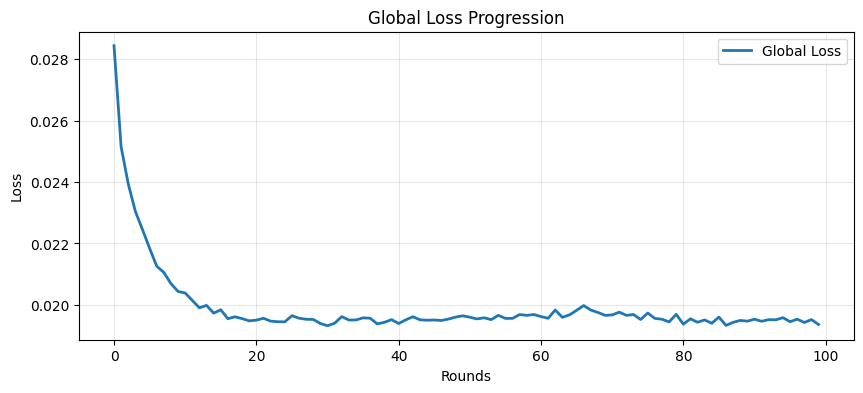

In [23]:
#Global loss progression 

plt.figure(figsize=(10, 4))
plt.plot(history["global_loss"], label="Global Loss", linewidth=2)
plt.title("Global Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

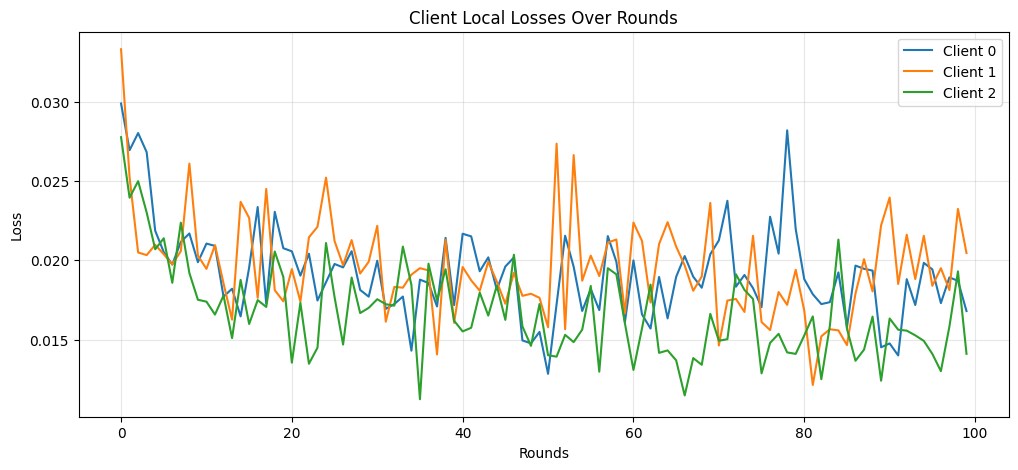

In [24]:
# Client local losses

plt.figure(figsize=(12, 5))
for c_idx in range(3):
    plt.plot(history["local_loss"][str(c_idx)], label=f"Client {c_idx}")
plt.title("Client Local Losses Over Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

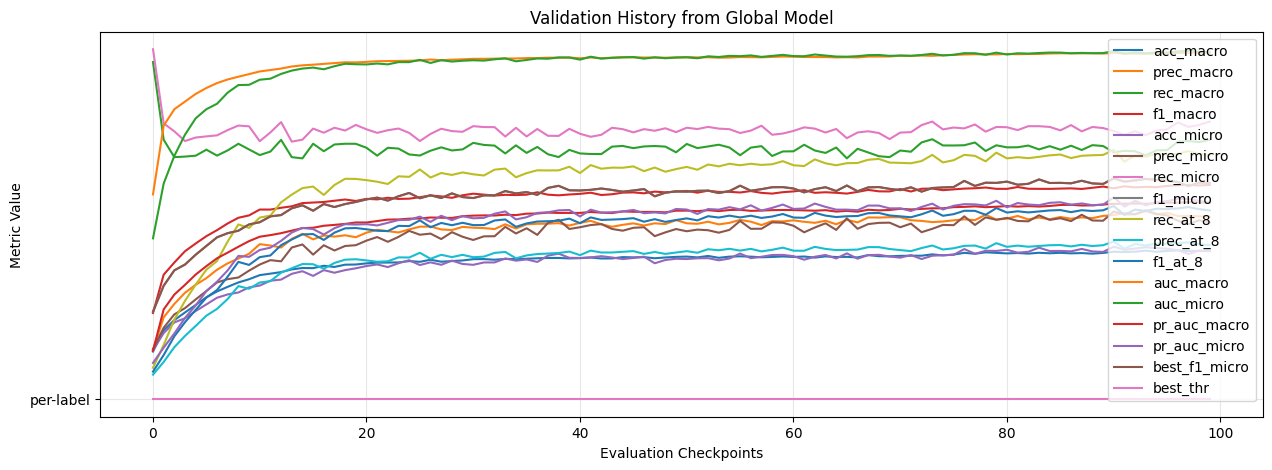

In [25]:
# Global validation metric overview

plt.figure(figsize=(15, 5))
plt.title("Validation History from Global Model")

# Plot each metric individually
for key in history["global_metrics"][0].keys():
    plt.plot([v[key] for v in history["global_metrics"]], label=key)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

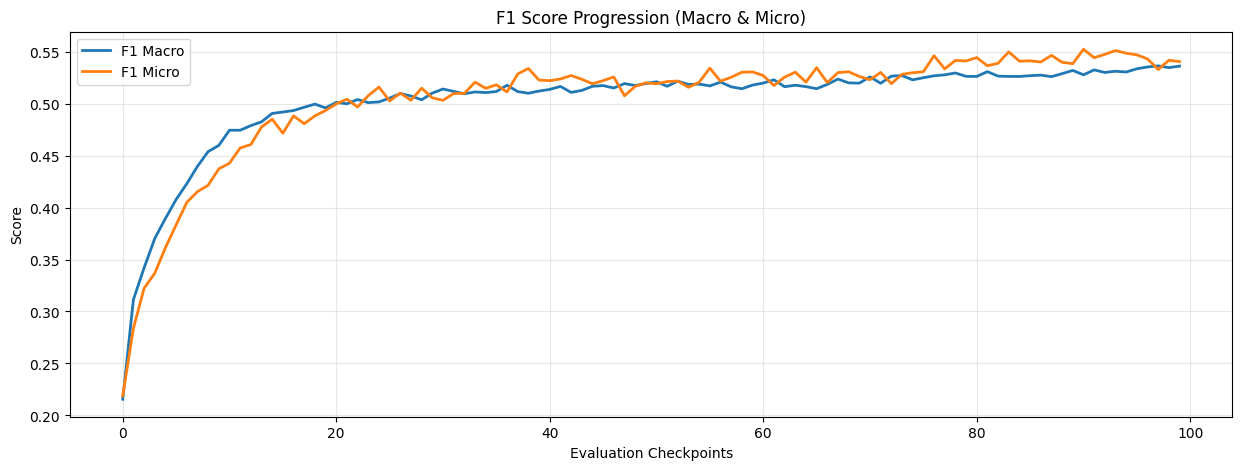

In [26]:
# F1 Score trends

plt.figure(figsize=(15, 5))
plt.title("F1 Score Progression (Macro & Micro)")
plt.plot([v["f1_macro"] for v in history["global_metrics"]], label="F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in history["global_metrics"]], label="F1 Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


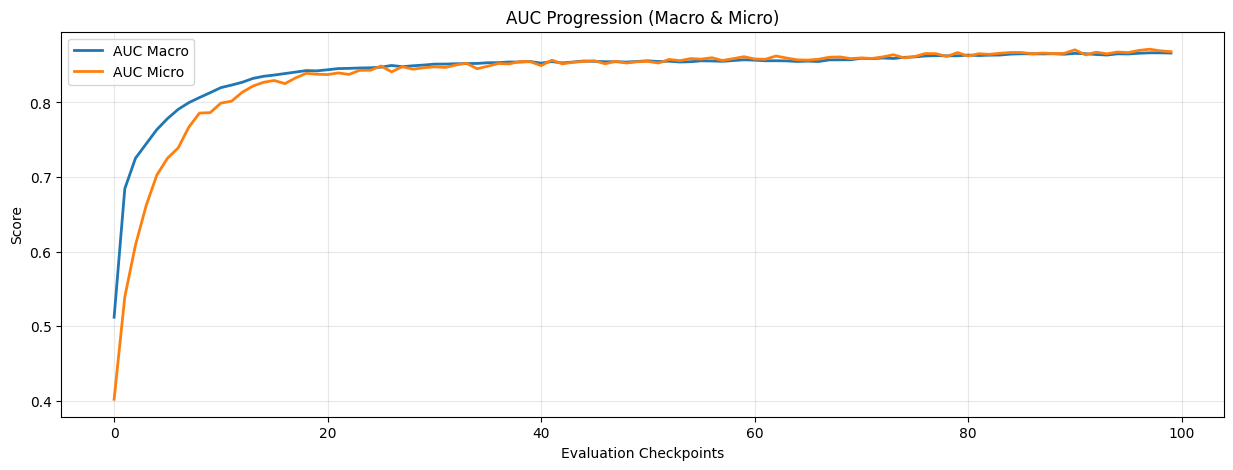

In [27]:
# AUC trends 

plt.figure(figsize=(15, 5))
plt.title("AUC Progression (Macro & Micro)")
plt.plot([v["auc_macro"] for v in history["global_metrics"]], label="AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in history["global_metrics"]], label="AUC Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Centralized Training (Baseline)

This section trains a **single centralized model** on all data combined,
using the **same configuration, metrics, and visualization pipeline** as the federated setup.

The centralized model acts as an upper performance bound for comparison.

In [ ]:
# Config - same as FL, but force BCE for the main reported centralized baseline

central_config = config.copy()
print(central_config)

{'batch_size': 32, 'lr': 0.002, 'n_filters': 21, 'window_size': 6, 'epochs': 3, 'rounds': 100, 'use_focal': False, 'gamma': 2.5}


In [26]:
# Centralized model initialization

central_model = GenerateModel(
    table_path=os.path.join("..", "Model", "processed_full.w2v"),
    num_of_filters=central_config["n_filters"],
    kernel_size=central_config["window_size"]
)

central_model.to(device)
val_loader = load_data(split="val")
train_loader = load_data(split="train")

# ---- Optional but recommended: bias init for fairness ----
n_labels = val_loader.dataset[0][1].shape[0]
pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

with torch.no_grad():
    p = pos_weight / (pos_weight + 1.0)
    prior_logit = torch.log(p / (1 - p))
    central_model.final.bias.copy_(prior_logit.clamp(-10, 10))

print("Centralized model and data ready.")

Centralized model and data ready.


In [27]:
# Centralized training history setup

central_history = {
    "train_loss": [],
    "val_loss": [],
    "metrics": []
}

cent_max_auc_macro = 0.0
cent_max_f1_micro = 0.0

CENTRAL_TRAIN_CSV = os.path.join(OUTPUT_DIR, "centralized_train_history.csv")
CENTRAL_EVAL_CSV = os.path.join(OUTPUT_DIR, "centralized_eval_history.csv")
CENTRAL_PROGRESS_JSON = os.path.join(OUTPUT_DIR, "centralized_progress.json")
CENTRAL_HISTORY_JSON = "../History/logs/central_metric_history.json"
CENTRAL_LATEST_MODEL = "../History/logs/latest_central_model.pt"
CENTRAL_MAX_AUC_MODEL = "../History/logs/max_central_auc.pt"
CENTRAL_MAX_F1_MODEL = "../History/logs/max_central_f1.pt"

In [28]:
# Centralized Training Loop

central_train_rows = []
central_eval_rows = []

resume_central = False
start_round = 0

if (
    resume_central
    and os.path.exists(CENTRAL_LATEST_MODEL)
    and os.path.exists(CENTRAL_HISTORY_JSON)
    and os.path.exists(CENTRAL_PROGRESS_JSON)
):
    print("Found centralized checkpoint. Resuming run...")

    central_model.load_state_dict(torch.load(CENTRAL_LATEST_MODEL, map_location=device))
    central_history = load_json(CENTRAL_HISTORY_JSON)
    progress = load_json(CENTRAL_PROGRESS_JSON)

    start_round = progress["last_completed_round"]

    if os.path.exists(CENTRAL_TRAIN_CSV):
        import pandas as pd
        central_train_rows = pd.read_csv(CENTRAL_TRAIN_CSV).to_dict(orient="records")

    if os.path.exists(CENTRAL_EVAL_CSV):
        import pandas as pd
        central_eval_rows = pd.read_csv(CENTRAL_EVAL_CSV).to_dict(orient="records")

    if len(central_history["metrics"]) > 0:
        cent_max_auc_macro = max(m["auc_macro"] for m in central_history["metrics"])
        cent_max_f1_micro = max(m["f1_micro"] for m in central_history["metrics"])

    print(f"Restarting at round {start_round + 1}")
else:
    print("No centralized checkpoint found. Starting fresh.")

optimizer = torch.optim.Adam(
    central_model.parameters(),
    lr=central_config["lr"],
    betas=(0.9, 0.99)
)

if central_config.get("use_focal", False):
    alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
    loss_fn = FocalLoss(alpha=alpha, gamma=central_config.get("gamma", 2.0))
else:
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

central_config["rounds"] = 100
target_evals = 100
eval_interval = max(1, round(central_config["rounds"] / target_evals))

for rnd in tqdm(range(start_round, central_config["rounds"]), colour="green"):
    central_model.train()
    total_loss = 0.0

    # ---- Training phase ----
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds, _ = central_model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    central_history["train_loss"].append(avg_train_loss)

    central_train_rows.append({
        "round": rnd + 1,
        "train_loss": float(avg_train_loss)
    })

    # ---- Evaluation + saving ----
    if (rnd + 1) % eval_interval == 0 or rnd == central_config["rounds"] - 1:
        _, per_label_thr = find_best_thresholds_per_label(central_model, val_loader, device)
        val_loss, metrics = eval_model(
            central_model,
            device,
            val_loader,
            per_label_thr=per_label_thr,
            use_focal=central_config["use_focal"],
            alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
            gamma=central_config["gamma"]
        )

        central_history["val_loss"].append(val_loss)
        central_history["metrics"].append(metrics)

        central_eval_rows.append({
            "round": rnd + 1,
            "train_loss": float(avg_train_loss),
            "val_loss": float(val_loss),
            **to_serializable_row(metrics)
        })

        save_json(central_history, CENTRAL_HISTORY_JSON)
        torch.save(central_model.state_dict(), CENTRAL_LATEST_MODEL)

        save_dict_rows_to_csv(central_train_rows, CENTRAL_TRAIN_CSV)
        save_dict_rows_to_csv(central_eval_rows, CENTRAL_EVAL_CSV)

        save_json(
            {
                "last_completed_round": rnd + 1,
                "rounds_total": central_config["rounds"],
                "eval_interval": eval_interval
            },
            CENTRAL_PROGRESS_JSON
        )

        if metrics["auc_macro"] > cent_max_auc_macro:
            cent_max_auc_macro = metrics["auc_macro"]
            torch.save(central_model.state_dict(), CENTRAL_MAX_AUC_MODEL)

        if metrics["f1_micro"] > cent_max_f1_micro:
            cent_max_f1_micro = metrics["f1_micro"]
            torch.save(central_model.state_dict(), CENTRAL_MAX_F1_MODEL)

        thr_display = metrics["best_thr"] if isinstance(metrics["best_thr"], str) else f"{metrics['best_thr']:.2f}"
        print(f"Round {rnd+1}/{central_config['rounds']} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"F1_micro: {metrics['f1_micro']:.4f} | "
              f"Best_F1: {metrics['best_f1_micro']:.4f} (thr={thr_display})")

print("Centralized training complete!")

save_dict_rows_to_csv(
    central_train_rows,
    CENTRAL_TRAIN_CSV
)

save_dict_rows_to_csv(
    central_eval_rows,
    CENTRAL_EVAL_CSV
)

best_f1, best_thr = find_best_threshold(central_model, val_loader, device)
print(f"Best threshold on validation set: {best_thr} (F1={best_f1:.4f})")

No centralized checkpoint found. Starting fresh.


  0%|          | 0/100 [00:00<?, ?it/s]

[Per-Label Thresholds] Macro F1=0.2663
[Eval Debug] Logit range: -1.51 to 1.90 | Sigmoid mean=0.494, std=0.070
[Eval] Avg loss=0.6803 | F1_micro=0.2659 | Best_F1=0.2659 @ thr=per-label | Avg labels/sample=25.06
Saved CSV: ..\History\original_comparison\centralized_train_history.csv
Saved CSV: ..\History\original_comparison\centralized_eval_history.csv


  1%|          | 1/100 [00:04<08:03,  4.88s/it]

Round 1/100 | Train Loss: 1.3880 | Val Loss: 0.6803 | F1_micro: 0.2659 | Best_F1: 0.2659 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.3306
[Eval Debug] Logit range: -4.58 to 3.02 | Sigmoid mean=0.465, std=0.158
[Eval] Avg loss=0.6289 | F1_micro=0.3276 | Best_F1=0.3276 @ thr=per-label | Avg labels/sample=18.98
Saved CSV: ..\History\original_comparison\centralized_train_history.csv
Saved CSV: ..\History\original_comparison\centralized_eval_history.csv


...

 99%|█████████▉| 99/100 [07:56<00:04,  4.95s/it]

Saved CSV: ..\History\original_comparison\centralized_train_history.csv
Saved CSV: ..\History\original_comparison\centralized_eval_history.csv
Round 99/100 | Train Loss: 0.6393 | Val Loss: 0.3973 | F1_micro: 0.6104 | Best_F1: 0.6104 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.5780
[Eval Debug] Logit range: -20.43 to 12.56 | Sigmoid mean=0.288, std=0.328
[Eval] Avg loss=0.3969 | F1_micro=0.6104 | Best_F1=0.6104 @ thr=per-label | Avg labels/sample=8.01


100%|██████████| 100/100 [08:00<00:00,  4.81s/it]

Saved CSV: ..\History\original_comparison\centralized_train_history.csv
Saved CSV: ..\History\original_comparison\centralized_eval_history.csv
Round 100/100 | Train Loss: 0.6388 | Val Loss: 0.3969 | F1_micro: 0.6104 | Best_F1: 0.6104 (thr=per-label)
Centralized training complete!
Saved CSV: ..\History\original_comparison\centralized_train_history.csv
Saved CSV: ..\History\original_comparison\centralized_eval_history.csv


Best threshold on validation set: 0.3 (F1=0.4482)


### Centralized Training Results Visualization

Plots below mirror the federated section for one-to-one comparison:
1. Training & validation loss  
2. Validation metrics overview  
3. F1 score trends  
4. AUC trends


In [35]:
# Load centralized history

central_history = load_json(filepath=CENTRAL_HISTORY_JSON)
print(f"Total Rounds Logged: {len(central_history['val_loss'])}")

Total Rounds Logged: 100


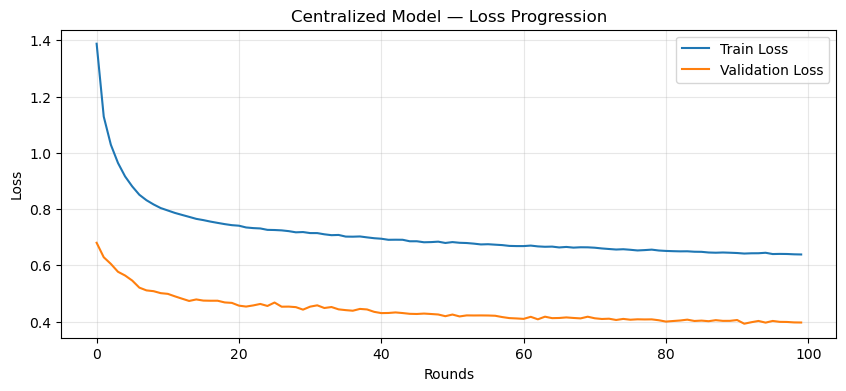

In [36]:
# Train and validation loss

plt.figure(figsize=(10, 4))
plt.plot(central_history["train_loss"], label="Train Loss")
plt.plot(central_history["val_loss"], label="Validation Loss")
plt.title("Centralized Model — Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [37]:
for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)
    preds, _ = central_model(X_batch)
    print("Pred shape:", preds.shape)
    print("Label shape:", y_batch.shape)
    print("Unique label values:", torch.unique(y_batch))
    break

Pred shape: torch.Size([32, 50])
Label shape: torch.Size([32, 50])
Unique label values: tensor([0., 1.], device='cuda:0', dtype=torch.float64)


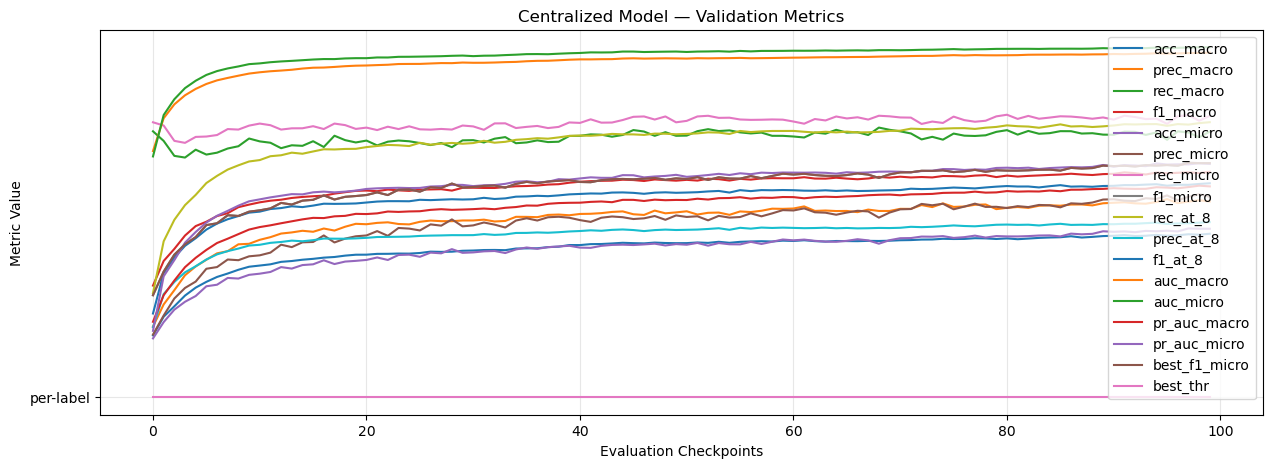

In [38]:
# Validation Metrics Overview

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — Validation Metrics")

for key in central_history["metrics"][0].keys():
    plt.plot([v[key] for v in central_history["metrics"]], label=key)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

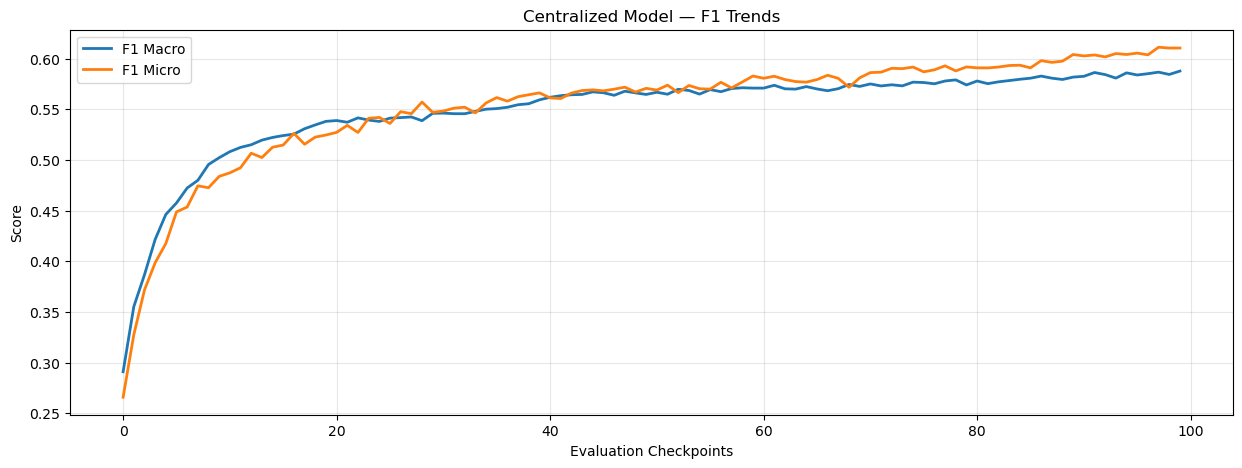

In [39]:
# F1 Score Trends

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — F1 Trends")
plt.plot([v["f1_macro"] for v in central_history["metrics"]], label="F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in central_history["metrics"]], label="F1 Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

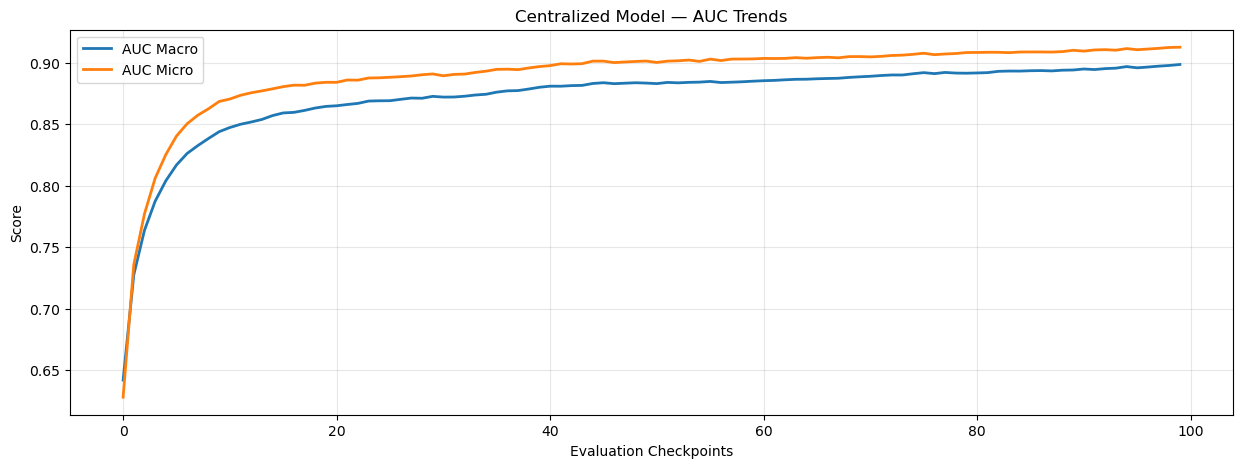

In [40]:
# AUC trends

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — AUC Trends")
plt.plot([v["auc_macro"] for v in central_history["metrics"]], label="AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in central_history["metrics"]], label="AUC Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Federated vs Centralized Comparison
 
This section compares the **Federated Learning (FL)** and **Centralized Training (CL)** experiments:
 
- Overlayed loss curves
- Validation metric trends
- Best-performing metrics summary (F1, AUC, etc.)
 
The goal is to analyze the trade-offs between distributed vs. centralized optimization.

In [41]:
# Load Both Training Histories

fed_history = load_json(filepath=FED_HISTORY_JSON)
central_history = load_json(filepath=CENTRAL_HISTORY_JSON)

print(f"FL rounds logged: {len(fed_history['global_loss'])}")
print(f"CL rounds logged: {len(central_history['val_loss'])}")

FL rounds logged: 100
CL rounds logged: 100


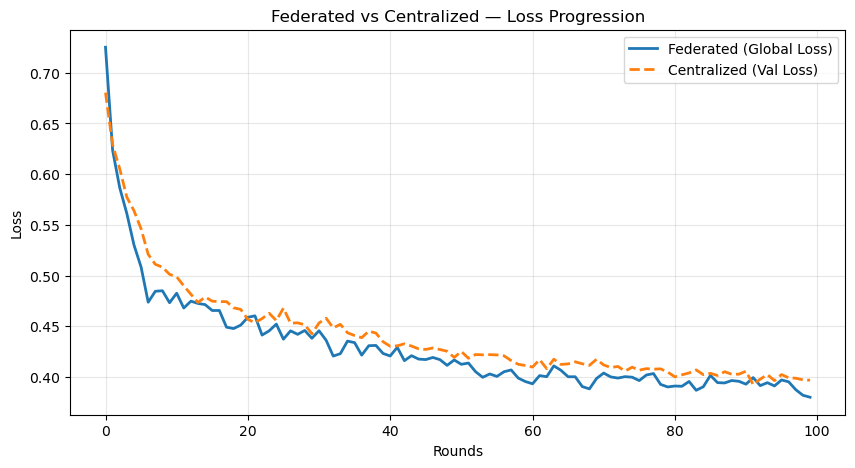

Saved CSV: ..\History\original_comparison\federated_vs_centralized_loss.csv


In [42]:
# FL vs Centralized - Loss Comparison

plt.figure(figsize=(10, 5))
plt.plot(fed_history["global_loss"], label="Federated (Global Loss)", linewidth=2)
plt.plot(central_history["val_loss"], label="Centralized (Val Loss)", linewidth=2, linestyle="--")
plt.title("Federated vs Centralized — Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

loss_comparison_rows = []
n_loss_points = min(len(fed_history["global_loss"]), len(central_history["val_loss"]))

for i in range(n_loss_points):
    loss_comparison_rows.append({
        "checkpoint": i + 1,
        "federated_global_loss": float(fed_history["global_loss"][i]),
        "centralized_val_loss": float(central_history["val_loss"][i])
    })

save_dict_rows_to_csv(
    loss_comparison_rows,
    os.path.join(OUTPUT_DIR, "federated_vs_centralized_loss.csv")
)

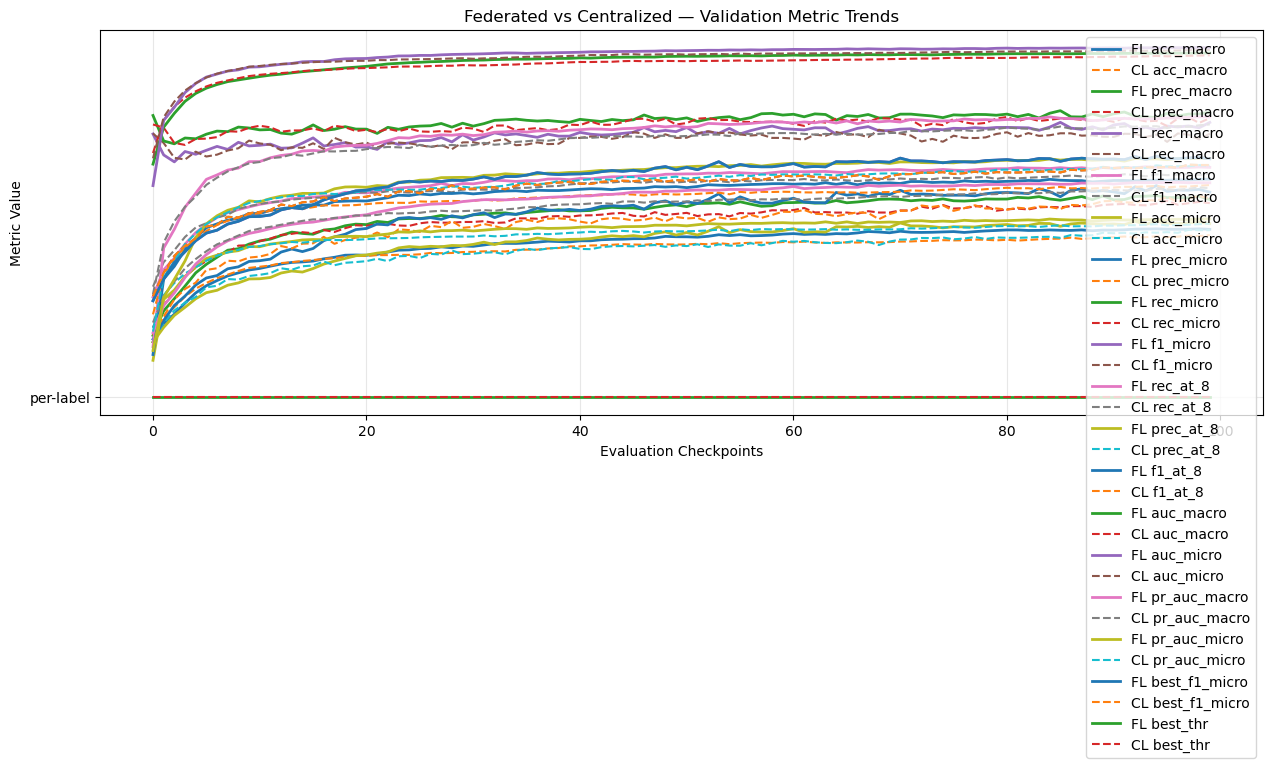

Saved CSV: ..\History\original_comparison\federated_vs_centralized_metric_trends.csv


In [43]:
# Federated vs Centralized — Validation Metric Trends

plt.figure(figsize=(15, 5))
plt.title("Federated vs Centralized — Validation Metric Trends")

fed_keys = fed_history["global_metrics"][0].keys()
cent_keys = central_history["metrics"][0].keys()

# Only plot overlapping metrics
shared_metrics = [k for k in fed_keys if k in cent_keys]

for key in shared_metrics:
    plt.plot([m[key] for m in fed_history["global_metrics"]],
             label=f"FL {key}", linewidth=2)
    plt.plot([m[key] for m in central_history["metrics"]],
             label=f"CL {key}", linestyle="--")

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

comparison_metric_rows = []
n_checkpoints = min(len(fed_history["global_metrics"]), len(central_history["metrics"]))

for i in range(n_checkpoints):
    row = {"checkpoint": i + 1}
    for key in shared_metrics:
        row[f"fl_{key}"] = fed_history["global_metrics"][i][key]
        row[f"cl_{key}"] = central_history["metrics"][i][key]
    comparison_metric_rows.append(to_serializable_row(row))

save_dict_rows_to_csv(
    comparison_metric_rows,
    os.path.join(OUTPUT_DIR, "federated_vs_centralized_metric_trends.csv")
)

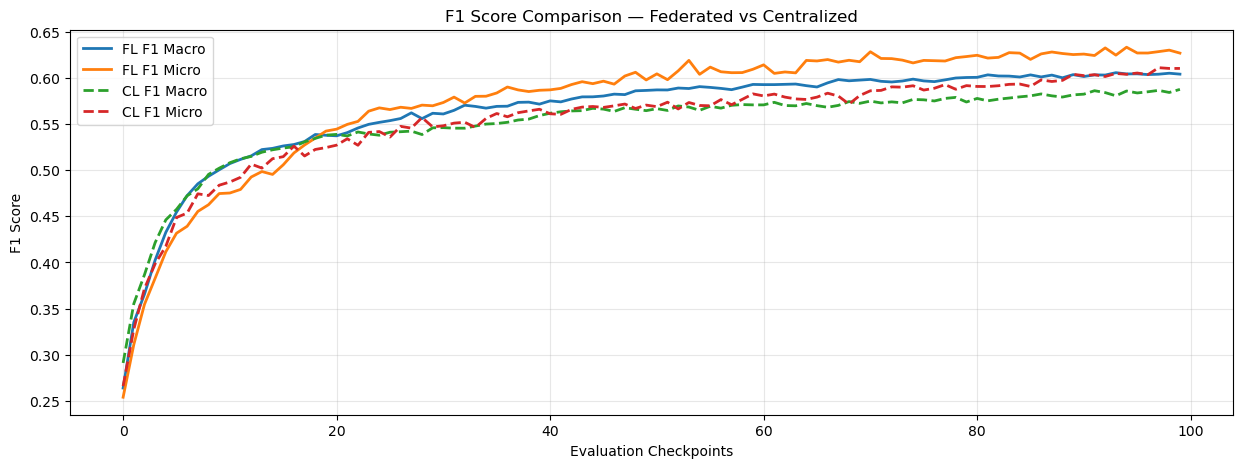

Saved CSV: ..\History\original_comparison\f1_comparison.csv


In [44]:
# F1 Comparison (Macro & Micro)

plt.figure(figsize=(15, 5))
plt.title("F1 Score Comparison — Federated vs Centralized")

plt.plot([v["f1_macro"] for v in fed_history["global_metrics"]], label="FL F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in fed_history["global_metrics"]], label="FL F1 Micro", linewidth=2)
plt.plot([v["f1_macro"] for v in central_history["metrics"]], label="CL F1 Macro", linestyle="--", linewidth=2)
plt.plot([v["f1_micro"] for v in central_history["metrics"]], label="CL F1 Micro", linestyle="--", linewidth=2)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

f1_comparison_rows = []
n_f1_points = min(len(fed_history["global_metrics"]), len(central_history["metrics"]))

for i in range(n_f1_points):
    f1_comparison_rows.append({
        "checkpoint": i + 1,
        "fl_f1_macro": float(fed_history["global_metrics"][i]["f1_macro"]),
        "fl_f1_micro": float(fed_history["global_metrics"][i]["f1_micro"]),
        "cl_f1_macro": float(central_history["metrics"][i]["f1_macro"]),
        "cl_f1_micro": float(central_history["metrics"][i]["f1_micro"])
    })

save_dict_rows_to_csv(
    f1_comparison_rows,
    os.path.join(OUTPUT_DIR, "f1_comparison.csv")
)

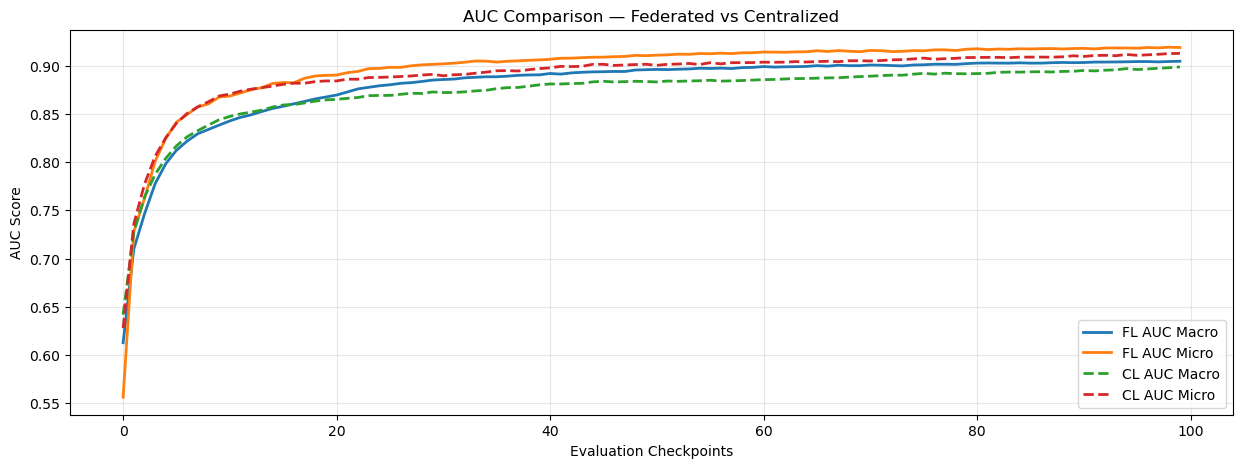

Saved CSV: ..\History\original_comparison\auc_comparison.csv


In [45]:
# AUC Comparison (Macro & Micro)

plt.figure(figsize=(15, 5))
plt.title("AUC Comparison — Federated vs Centralized")

plt.plot([v["auc_macro"] for v in fed_history["global_metrics"]], label="FL AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in fed_history["global_metrics"]], label="FL AUC Micro", linewidth=2)
plt.plot([v["auc_macro"] for v in central_history["metrics"]], label="CL AUC Macro", linestyle="--", linewidth=2)
plt.plot([v["auc_micro"] for v in central_history["metrics"]], label="CL AUC Micro", linestyle="--", linewidth=2)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

auc_comparison_rows = []
n_auc_points = min(len(fed_history["global_metrics"]), len(central_history["metrics"]))

for i in range(n_auc_points):
    auc_comparison_rows.append({
        "checkpoint": i + 1,
        "fl_auc_macro": float(fed_history["global_metrics"][i]["auc_macro"]),
        "fl_auc_micro": float(fed_history["global_metrics"][i]["auc_micro"]),
        "cl_auc_macro": float(central_history["metrics"][i]["auc_macro"]),
        "cl_auc_micro": float(central_history["metrics"][i]["auc_micro"])
    })

save_dict_rows_to_csv(
    auc_comparison_rows,
    os.path.join(OUTPUT_DIR, "auc_comparison.csv")
)

In [46]:
# Quantitative Comparison — Best Scores

fed_best_f1 = max([m["f1_micro"] for m in fed_history["global_metrics"]])
fed_best_auc = max([m["auc_macro"] for m in fed_history["global_metrics"]])

cent_best_f1 = max([m["f1_micro"] for m in central_history["metrics"]])
cent_best_auc = max([m["auc_macro"] for m in central_history["metrics"]])

print("Federated vs Centralized Results Summary")
print(f"Federated  → Best F1 (micro): {fed_best_f1:.4f} | Best AUC (macro): {fed_best_auc:.4f}")
print(f"Centralized → Best F1 (micro): {cent_best_f1:.4f} | Best AUC (macro): {cent_best_auc:.4f}")

comparison_rows = [
    {
        "model": "federated",
        "best_f1_micro": float(fed_best_f1),
        "best_auc_macro": float(fed_best_auc)
    },
    {
        "model": "centralized",
        "best_f1_micro": float(cent_best_f1),
        "best_auc_macro": float(cent_best_auc)
    }
]

save_dict_rows_to_csv(
    comparison_rows,
    os.path.join(OUTPUT_DIR, "best_scores_summary.csv")
)

Federated vs Centralized Results Summary
Federated  → Best F1 (micro): 0.6334 | Best AUC (macro): 0.9044
Centralized → Best F1 (micro): 0.6112 | Best AUC (macro): 0.8986
Saved CSV: ..\History\original_comparison\best_scores_summary.csv


## Threshold Analysis (Per-Label vs Global)

In [47]:
print(history["global_metrics"][-3:])
print(central_history["metrics"][-3:])

[{'acc_macro': np.float64(0.44199100931889895), 'prec_macro': np.float64(0.5241592668488064), 'rec_macro': np.float64(0.7129668848733943), 'f1_macro': np.float64(0.6041553630443869), 'acc_micro': np.float64(0.4584030520045512), 'prec_micro': np.float64(0.5442193087008343), 'rec_micro': np.float64(0.7440521455730581), 'f1_micro': np.float64(0.6286369894446994), 'rec_at_8': np.float64(0.7350826349667517), 'prec_at_8': np.float64(0.46698698078115314), 'f1_at_8': np.float64(0.5711383364668099), 'auc_macro': np.float64(0.9037906132094393), 'auc_micro': np.float64(0.9183412986115855), 'pr_auc_macro': np.float64(0.5638244226902728), 'pr_auc_micro': np.float64(0.626893818810208), 'best_f1_micro': np.float64(0.6286369894446994), 'best_thr': 'per-label'}, {'acc_macro': np.float64(0.4428446642450045), 'prec_macro': np.float64(0.5283602851589378), 'rec_macro': np.float64(0.7082507438979476), 'f1_macro': np.float64(0.6052211345637858), 'acc_micro': np.float64(0.4601235230934479), 'prec_micro': np.f

[Per-Label Thresholds] Macro F1=0.5780
[Eval Debug] Logit range: -20.43 to 12.56 | Sigmoid mean=0.288, std=0.328


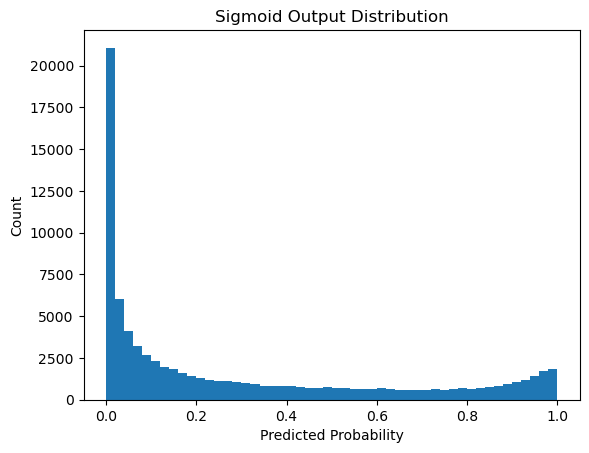

[Eval] Avg loss=0.3969 | F1_micro=0.6104 | Best_F1=0.6104 @ thr=per-label | Avg labels/sample=8.01


In [48]:
macro_f1, per_label_thr = find_best_thresholds_per_label(central_model, val_loader, device)
val_loss, metrics = eval_model(
    central_model,
    device,
    val_loader,
    per_label_thr=per_label_thr,
    sigmoid=True,
    use_focal=central_config["use_focal"],
    alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
    gamma=central_config["gamma"]
)

Per-label thresholds:
 tensor([0.8500, 0.9000, 0.7000, 0.8000, 0.7500, 0.8000, 0.8000, 0.8000, 0.4500,
        0.7500, 0.7500, 0.7000, 0.7000, 0.8500, 0.8500, 0.9000, 0.6500, 0.5500,
        0.9000, 0.8000, 0.4500, 0.8500, 0.9000, 0.9000, 0.7500, 0.9000, 0.6500,
        0.6500, 0.9000, 0.8000, 0.8500, 0.8500, 0.8500, 0.8000, 0.7000, 0.6500,
        0.9000, 0.8500, 0.9000, 0.8500, 0.7000, 0.6500, 0.6500, 0.9000, 0.6000,
        0.8500, 0.8500, 0.7000, 0.9000, 0.9000])
Min threshold: 0.450
Max threshold: 0.900
Mean threshold: 0.778
Std dev: 0.117


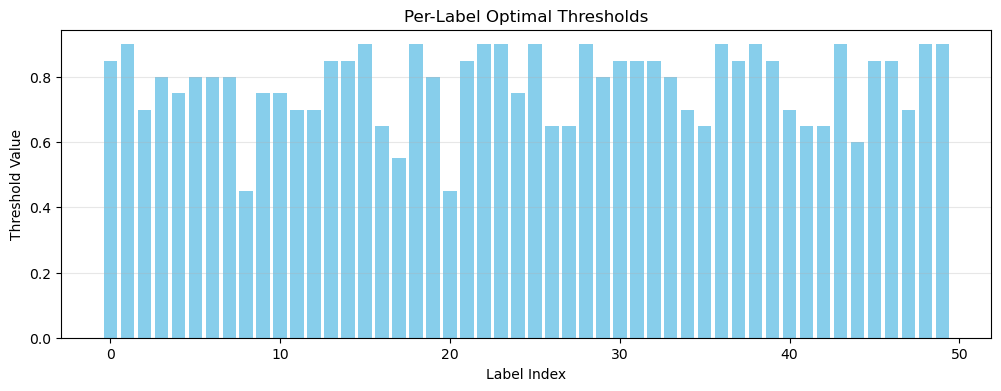

In [49]:
print("Per-label thresholds:\n", per_label_thr)
print(f"Min threshold: {per_label_thr.min():.3f}")
print(f"Max threshold: {per_label_thr.max():.3f}")
print(f"Mean threshold: {per_label_thr.mean():.3f}")
print(f"Std dev: {per_label_thr.std():.3f}")

torch.save(per_label_thr, "../History/logs/per_label_thresholds.pt")

plt.figure(figsize=(12, 4))
plt.bar(np.arange(len(per_label_thr)), per_label_thr.cpu().numpy(), color='skyblue')
plt.title("Per-Label Optimal Thresholds")
plt.xlabel("Label Index")
plt.ylabel("Threshold Value")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [50]:
macro_f1_global, _ = find_best_threshold(central_model, val_loader, device)
macro_f1_per_label, _ = find_best_thresholds_per_label(central_model, val_loader, device)

print(f"Global tuned F1: {macro_f1_global:.4f}")
print(f"Per-label tuned F1: {macro_f1_per_label:.4f}")

[Per-Label Thresholds] Macro F1=0.5780
Global tuned F1: 0.4482
Per-label tuned F1: 0.5780


## Test Set Comparison

In [51]:
# --- Test set evaluation (for paper comparison) ---
test_loader = load_data(split="test")

# Load best-performing models (selected by validation F1_micro)
central_model.load_state_dict(torch.load(CENTRAL_MAX_F1_MODEL, map_location=device))
Global_Model.load_state_dict(torch.load(FED_MAX_F1_MODEL, map_location=device))

# Compute per-label thresholds from validation set separately for each model
_, thr_c = find_best_thresholds_per_label(central_model, val_loader, device)
_, thr_f = find_best_thresholds_per_label(Global_Model, val_loader, device)

# ---- Centralized Test Evaluation ----
test_loss_c, test_metrics_c = eval_model(
    central_model,
    device,
    test_loader,
    per_label_thr=thr_c,
    use_focal=central_config["use_focal"],  # only affects reported loss, not thresholded metrics
    alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
    gamma=central_config["gamma"]
)
print(f"Centralized Test — F1_micro={test_metrics_c['f1_micro']:.3f}, "
      f"F1_macro={test_metrics_c['f1_macro']:.3f}, "
      f"AUC_micro={test_metrics_c['auc_micro']:.3f}, "
      f"AUC_macro={test_metrics_c['auc_macro']:.3f}")

# ---- Federated Test Evaluation ----
test_loss_f, test_metrics_f = eval_model(
    Global_Model,
    device,
    test_loader,
    per_label_thr=thr_f,
    use_focal=config["use_focal"],
    alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
    gamma=config["gamma"]
)
print(f"Federated Test — F1_micro={test_metrics_f['f1_micro']:.3f}, "
      f"F1_macro={test_metrics_f['f1_macro']:.3f}, "
      f"AUC_micro={test_metrics_f['auc_micro']:.3f}, "
      f"AUC_macro={test_metrics_f['auc_macro']:.3f}")

test_rows = [
    {
        "model": "centralized",
        "checkpoint_selection": "best_val_f1_micro",
        "threshold_source": "centralized_validation",
        "test_loss": float(test_loss_c),
        **to_serializable_row(test_metrics_c)
    },
    {
        "model": "federated",
        "checkpoint_selection": "best_val_f1_micro",
        "threshold_source": "federated_validation",
        "test_loss": float(test_loss_f),
        **to_serializable_row(test_metrics_f)
    }
]

save_dict_rows_to_csv(
    test_rows,
    os.path.join(OUTPUT_DIR, "test_results.csv")
)

test_threshold_rows = [
    {
        "model": "centralized",
        "min_threshold": float(thr_c.min()),
        "max_threshold": float(thr_c.max()),
        "mean_threshold": float(thr_c.mean()),
        "std_threshold": float(thr_c.std())
    },
    {
        "model": "federated",
        "min_threshold": float(thr_f.min()),
        "max_threshold": float(thr_f.max()),
        "mean_threshold": float(thr_f.mean()),
        "std_threshold": float(thr_f.std())
    }
]

save_dict_rows_to_csv(
    test_threshold_rows,
    os.path.join(OUTPUT_DIR, "test_threshold_summary.csv")
)

[Per-Label Thresholds] Macro F1=0.5767
[Per-Label Thresholds] Macro F1=0.5967
[Eval Debug] Logit range: -17.05 to 10.50 | Sigmoid mean=0.296, std=0.329
[Eval] Avg loss=0.3970 | F1_micro=0.6121 | Best_F1=0.6121 @ thr=per-label | Avg labels/sample=8.20
Centralized Test — F1_micro=0.612, F1_macro=0.599, AUC_micro=0.912, AUC_macro=0.895
[Eval Debug] Logit range: -15.69 to 11.82 | Sigmoid mean=0.288, std=0.333
[Eval] Avg loss=0.3871 | F1_micro=0.6320 | Best_F1=0.6320 @ thr=per-label | Avg labels/sample=7.54
Federated Test — F1_micro=0.632, F1_macro=0.611, AUC_micro=0.918, AUC_macro=0.900
Saved CSV: ..\History\original_comparison\test_results.csv
Saved CSV: ..\History\original_comparison\test_threshold_summary.csv
